## Lesson 2.1 极简代码：确定性映射的“骨架”

正在构建确定性路由表...
正在计算矩阵特征值...


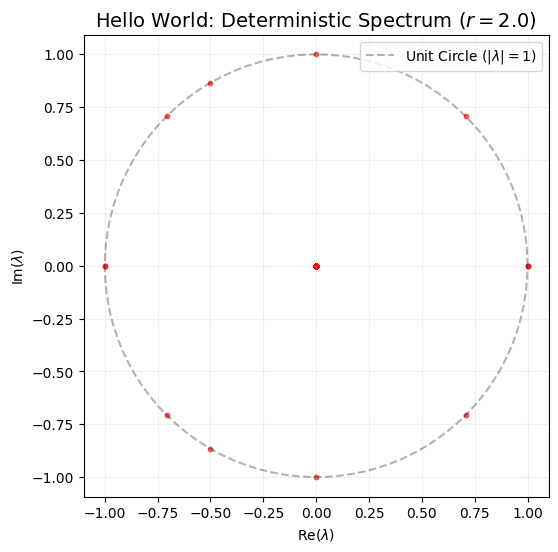

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. 初始化参数与空间划分 (把连续的宇宙切成 1000 个离散的“方格”)
# =================================================================
r = 2.0      # 我们的魔法参数：强混沌状态
N = 1000     # 划分的方格数量

edges = np.linspace(-1, 1, N + 1)
centers = (edges[:-1] + edges[1:]) / 2

# 初始化转移矩阵 P (我们的“状态路由表”)
P = np.zeros((N, N))

# =================================================================
# 2. 核心：最暴力的确定性映射 (物理规则的极简翻译)
# =================================================================
print("正在构建确定性路由表...")
for j in range(N):
    # 提取当前方格 j 的中心点，代入动力学方程，算出下一步飞去哪
    x_next = 1 - r * (centers[j]**2)
    
    # 暴力定位：利用二分查找，看新位置落在了哪个方格 i
    # (因为 r=2.0 时 x_next 绝对在 [-1, 1] 内，所以直接减 1 即为索引)
    i = np.searchsorted(edges, x_next) - 1
    
    # 记账：从方格 j (出发地) 到方格 i (目的地) 的转移概率是 100%
    P[i, j] = 1.0  

# =================================================================
# 3. 抽取灵魂：计算特征值
# =================================================================
print("正在计算矩阵特征值...")
eigenvalues = np.linalg.eigvals(P)

# =================================================================
# 4. 可视化：见证神奇的“单位圆”与“原点黑洞”
# =================================================================
plt.figure(figsize=(6, 6))

# 画出作为参照的单位圆 (模长 |λ| = 1)
theta = np.linspace(0, 2*np.pi, 100)

# 【核心修复】：使用 r"" 原始字符串前缀，完美解决 \lambda 带来的 SyntaxWarning
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label=r"Unit Circle $(|\lambda|=1)$")

# 画出真实算出的特征值散点
plt.scatter(eigenvalues.real, eigenvalues.imag, s=10, c='red', alpha=0.6)

# 同样使用 r"" 前缀保护 LaTeX 公式
plt.title(rf"Hello World: Deterministic Spectrum ($r={r}$)", fontsize=14)
plt.xlabel(r"Re($\lambda$)")
plt.ylabel(r"Im($\lambda$)")
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.legend()
plt.show()

### 课堂讲义：如何向 CS 和数学系学生解释这个 Hello World？

当这张只有“一个红圈”和“一坨原点”的图跑出来时，这不仅是一个物理问题，更是一个绝佳的计算机科学和图论（Graph Theory）的教学切入点。

你可以用网页搜索 Ranking 或倒排索引的底层逻辑来做比喻，瞬间打通 CS 学生的思维脉络：

**1. 矩阵 `P` 到底是什么？（路由表/状态机）**
在这段最简代码里，矩阵  的每一列只有一个 `1.0`，其余全为 `0`。
这意味着，我们把一个复杂的连续物理过程，降维成了一个**极其死板的有限状态机（Finite State Machine）**。这就像在构建一个强关联的倒排索引表或网页跳转路由，方格  无脑且 100% 确定地指向方格 。没有任何的模棱两可，没有任何的扩散。

**2. 为什么特征值全跑到了单位圆上，或者死在了原点？**
这是这节课最核心的数学/物理交汇点。
由于每个状态只能指向一个固定的下一个状态，整个系统的演化轨迹最终只有两种命运：

* **命运 A：进入死循环（周期轨道）。** 在有向图里，这意味着走入了一个闭环（Cycle）。在矩阵代数中，一个长度为  的完美闭环，其特征值必然是  次单位根（Roots of Unity）。这就解释了为什么红点像钟表的刻度一样，完美地排列在虚线表示的单位圆上（模长 ）。
* **命运 B：成为炮灰（瞬态）。** 如果某些方格永远不可能被别的方格跳进来（这在物理上叫“非游荡集”外的点），它们在矩阵里就代表了不可逆的衰减。经过几次演化，它们的信息就彻底丢失了。这在特征值图上，就表现为死死扎堆在坐标原点（）的那一坨红点。

**3. 引发深思（桥接真正的混沌）**

> “同学们，大自然的动力学，真的是这么死板的 1 和 0 吗？
> 在真实的物理世界（或我们做具身智能、环境模拟时），测量总有误差，气流总有扰动。一个小球落在方格边缘，它绝不会 100% 去某一个方格，而是有一定的概率‘溢出’到相邻方格。
> 只要我们在刚才的 `P[i, j] = 1.0` 里，揉进极其微小的一点点高斯噪声（也就是物理学中的‘扩散算子’），这堵死板的墙就会瞬间倒塌。单位圆上的红点会像冰山一样向内坍缩，这就是我们下一节课要展示的真正的‘混沌谱指纹’！”

用这个 Hello World 作为开场，不仅代码极短、没有任何认知门槛，而且完美地建立了一个“树靶子”的过程：**先用纯计算机的确定性逻辑构造一个僵硬的系统，然后再引入物理学的‘噪声与概率’赋予其生命。** 这样的课程递进逻辑，堪称完美。